In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
import os

/home/EddyPerondini/.pyenv/versions/3.12.2/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:

path = kagglehub.dataset_download("fedesoriano/stellar-classification-dataset-sdss17")

print("Path to dataset files:", path)

Path to dataset files: /home/EddyPerondini/.cache/kagglehub/datasets/fedesoriano/stellar-classification-dataset-sdss17/versions/1


## Descrição da base de dados: 

- obj_ID = Object Identifier, the unique value that identifies the object in the image catalog used by the CAS
- alpha = Right Ascension angle (at J2000 epoch)
- delta = Declination angle (at J2000 epoch)
- u = Ultraviolet filter in the photometric system
- g = Green filter in the photometric system
- r = Red filter in the photometric system
- i = Near Infrared filter in the photometric system
- z = Infrared filter in the photometric system
- run_ID = Run Number used to identify the specific scan
- rereun_ID = Rerun Number to specify how the image was processed
- cam_col = Camera column to identify the scanline within the run
- field_ID = Field number to identify each field
- spec_obj_ID = Unique ID used for optical spectroscopic objects (this means that 2 different observations with the same spec_obj_ID must share the output class)
- class = object class (galaxy, star or quasar object)
- redshift = redshift value based on the increase in wavelength
- plate = plate ID, identifies each plate in SDSS
- MJD = Modified Julian Date, used to indicate when a given piece of SDSS data was taken
- fiber_ID = fiber ID that identifies the fiber that pointed the light at the focal plane in each observation

In [3]:
os.listdir(path)

df = pd.read_csv(f'{path}/star_classification.csv')

df.head()

,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,class,redshift,plate,MJD,fiber_ID
0,1.237661e+18,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,3606,301,2,79,6.543777e+18,GALAXY,0.634794,5812,56354,171
1,1.237665e+18,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,4518,301,5,119,1.176014e+19,GALAXY,0.779136,10445,58158,427
2,1.237661e+18,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,3606,301,2,120,5.152200e+18,GALAXY,0.644195,4576,55592,299
3,1.237663e+18,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,4192,301,3,214,1.030107e+19,GALAXY,0.932346,9149,58039,775
4,1.237680e+18,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,8102,301,3,137,6.891865e+18,GALAXY,0.116123,6121,56187,842


In [7]:
df.shape

(100000, 18)

In [16]:
from sklearn.preprocessing import LabelEncoder
# Contar as classes

label = LabelEncoder()

df['class'] = label.fit_transform(df['class'])

df_galaxy = df[df['class'] == 0][:25000]

df_qso = df[df['class'] == 1]

df_star = df[df['class'] == 2]

# df1 = pd.concat([df_galaxy, df_star], axis = 0)

# df2 = pd.concat([df1, df_qso], axis = 0)

df_final = pd.concat([df_galaxy, df_qso, df_star], axis = 0)

# galaxias = len(df[df['class'] == 'GALAXY'])
# quasares = len(df[df['class'] == 'QSO'])
# estrelas = len(df[df['class'] == 'STAR'])

df_final


# print('Estrelas:', estrelas)
# print('Quasares:', quasares)
# print('Galaxias:', galaxias)
# print('Total:', galaxias + estrelas + quasares)
# sns.countplot(data = df_final, x = 'class', hue = 'class')
# plt.legend(['GALAXY', 'QSO', 'STAR'])
# plt.show()


,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,class,redshift,plate,MJD,fiber_ID
0,1.237661e+18,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,3606,301,2,79,6.543777e+18,0,0.634794,5812,56354,171
1,1.237665e+18,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,4518,301,5,119,1.176014e+19,0,0.779136,10445,58158,427
2,1.237661e+18,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,3606,301,2,120,5.152200e+18,0,0.644195,4576,55592,299
3,1.237663e+18,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,4192,301,3,214,1.030107e+19,0,0.932346,9149,58039,775
4,1.237680e+18,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,8102,301,3,137,6.891865e+18,0,0.116123,6121,56187,842
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99931,1.237680e+18,338.557124,24.678940,26.03642,23.55800,21.91035,20.74742,19.72344,8109,301,3,100,8.616681e+18,2,-0.000070,7653,57306,613
99939,1.237680e+18,355.651889,27.734322,24.87293,20.71855,19.83588,19.54439,19.43266,8103,301,5,70,7.336558e+18,2,-0.000778,6516,56571,706
99941,1.237661e+18,251.031744,31.840055,23.25934,22.93305,21.72368,20.44625,19.73752,3705,301,2,335,1.229506e+19,2,-0.000153,10920,58252,833
99955,1.237671e+18,172.281648,-8.909060,22.26657,20.76710,20.22759,20.08172,19.98396,5982,301,2,120,3.238115e+18,2,-0.000395,2876,54581,98


In [16]:
#Será que existem valores nulos presentes nessa base de dados? 

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 18 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   obj_ID       100000 non-null  float64
 1   alpha        100000 non-null  float64
 2   delta        100000 non-null  float64
 3   u            100000 non-null  float64
 4   g            100000 non-null  float64
 5   r            100000 non-null  float64
 6   i            100000 non-null  float64
 7   z            100000 non-null  float64
 8   run_ID       100000 non-null  int64  
 9   rerun_ID     100000 non-null  int64  
 10  cam_col      100000 non-null  int64  
 11  field_ID     100000 non-null  int64  
 12  spec_obj_ID  100000 non-null  float64
 13  class        100000 non-null  object 
 14  redshift     100000 non-null  float64
 15  plate        100000 non-null  int64  
 16  MJD          100000 non-null  int64  
 17  fiber_ID     100000 non-null  int64  
dtypes: float64(10), int64(7),

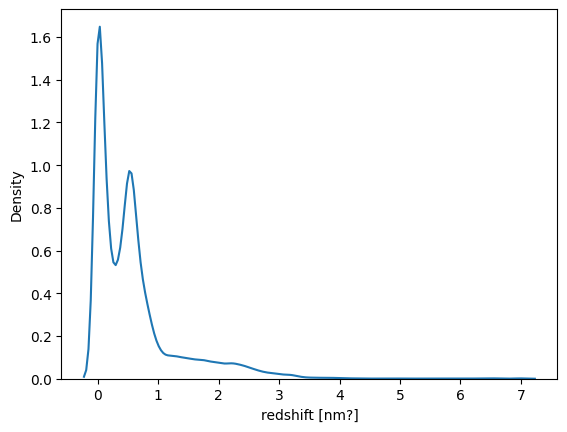

In [19]:
#Plotando distruições 

sns.kdeplot(data = df, x = 'redshift')
plt.xlabel('redshift [nm?]')
plt.show()

In [26]:
#Contando os IDs 

print('Valores Unicos RUN_ID:',df['run_ID'].nunique())

print('Valores Unicos RERUN_ID:',df['rerun_ID'].nunique())

print('Valores Unicos CAM_COL:',df['cam_col'].nunique())

print('Valores Unicos FIELD_ID:',df['field_ID'].nunique())

print('---------------------')
print('TOTAL:',df['run_ID'].__len__())

Valores Unicos RUN_ID: 430
Valores Unicos RERUN_ID: 1
Valores Unicos CAM_COL: 6
Valores Unicos FIELD_ID: 856
---------------------
TOTAL: 100000


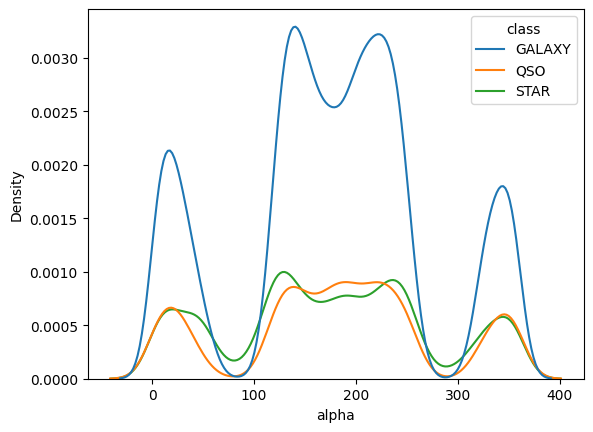

In [27]:
#Observando distribuições por classe 

sns.kdeplot(data = df, x = 'alpha', hue = 'class')
plt.show()

83.00051858898 -18.7853280771825


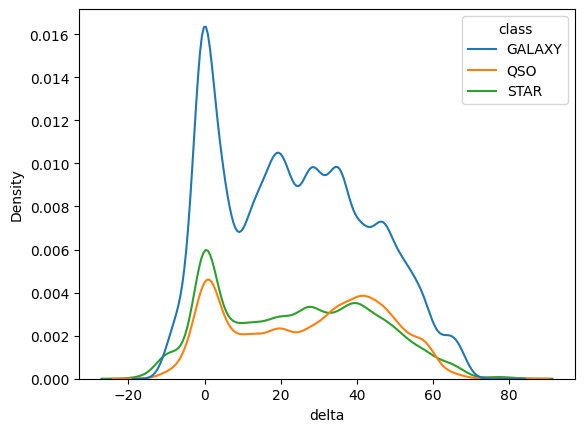

In [29]:
max_delta = max(df['delta'])
min_delta = min(df['delta'])

print(max_delta, min_delta)

sns.kdeplot(data = df, x = 'delta', hue = 'class')
plt.show()

In [37]:
df.loc[df['u'] == -9999]

,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,class,redshift,plate,MJD,fiber_ID
79543,1.237649e+18,224.006526,-0.624304,-9999.0,-9999.0,18.1656,18.01675,-9999.0,752,301,2,537,3.731277e+18,STAR,0.000089,3314,54970,162


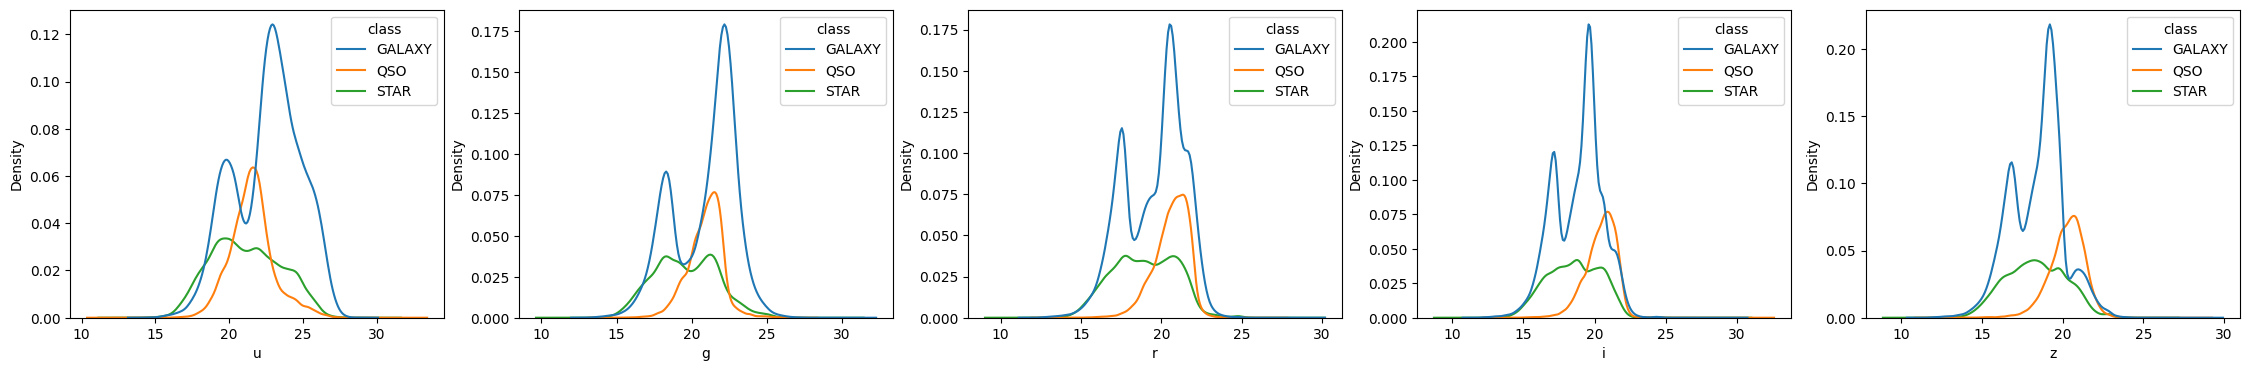

In [ ]:
df_filtrado = df[df['u'] > -9998] #Esse valor é um outlayer

fig, ax = plt.subplots(1,5, figsize = (28,4))

sns.kdeplot(data = df_filtrado, x = 'u', hue = 'class', ax = ax[0])
sns.kdeplot(data = df_filtrado, x = 'g', hue = 'class', ax = ax[1])
sns.kdeplot(data = df_filtrado, x = 'r', hue = 'class', ax = ax[2])
sns.kdeplot(data = df_filtrado, x = 'i', hue = 'class', ax = ax[3])
sns.kdeplot(data = df_filtrado, x = 'z', hue = 'class', ax = ax[4])
plt.show()